# Week 3, Day 2, Afternoon Session
## Sorting

In [10]:
import time
import functools
!wget https://raw.githubusercontent.com/jamcoders/syllabus-resources-2023/main/week3/lecs/boaz_utils.ipynb
%run "boaz_utils.ipynb"

--2026-07-21 11:35:15--  https://raw.githubusercontent.com/jamcoders/syllabus-resources-2023/main/week3/lecs/boaz_utils.ipynb
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 33782 (33K) [text/plain]
Saving to: ‘boaz_utils.ipynb.5’

boaz_utils.ipynb.5  100%[===================>]  32.99K  --.-KB/s    in 0.006s  

2026-07-21 11:35:15 (4.98 MB/s) - ‘boaz_utils.ipynb.5’ saved [33782/33782]



In [2]:
L = [4,1,3,2]
print(sorted(L))

[1, 2, 3, 4]


In [6]:
def make_comparator(key):
    def compare(x,y):
        if x[key] < y[key]:
            return -1
        elif x[key] > y[key]:
            return 1
        else:
            return 0
    return compare

In [7]:
runners = [
    {'firstname':'Shelly-Ann', 'lastname':'Fraser-Pryce', 'country':'JAM', 'time':10.67},
    {'firstname':'Shericka', 'lastname':'Jackson', 'country':'JAM', 'time':10.73},
    {'firstname':'Elaine', 'lastname':'Thompson-Herah', 'country':'JAM', 'time':10.81},
    {'firstname':'Dina', 'lastname':'Asher-Smith', 'country':'GBR', 'time':10.83},
    {'firstname':'Mujinga', 'lastname':'Kambundji', 'country':'SUI', 'time':10.91},
    {'firstname':'Aleia', 'lastname':'Hobbs', 'country':'USA', 'time':10.92},
    {'firstname':'Marie Josée', 'lastname':'Ta Lou', 'country':'CIV', 'time':10.93},
    {'firstname':'Melissa', 'lastname':'Jefferson', 'country':'USA', 'time':11.03},

]

In [8]:
def print_runners(L):
    for x in L:
        print(x['firstname'].ljust(15) + ' ' + (x['lastname'].upper() + ',').ljust(20) + ' ' + x['country'].ljust(3) + ', ' + str(x['time']))

In [9]:
print_runners(sorted(runners, key=functools.cmp_to_key(make_comparator('time'))))

Shelly-Ann      FRASER-PRYCE,        JAM, 10.67
Shericka        JACKSON,             JAM, 10.73
Elaine          THOMPSON-HERAH,      JAM, 10.81
Dina            ASHER-SMITH,         GBR, 10.83
Mujinga         KAMBUNDJI,           SUI, 10.91
Aleia           HOBBS,               USA, 10.92
Marie Josée     TA LOU,              CIV, 10.93
Melissa         JEFFERSON,           USA, 11.03


**What is a good way to sort?**

**Simple algorithm**: find smallest item and move to position 0, then the next smallest to position 1, etc...

## **SelectionSort** takes $O(n^2)$ time. 

## Recursive implementation

In [21]:
# return the index of the minimum element of the list
def find_min_index(L):
    # base case
    if len(L) == 1:
        return 0
    # recursive step
    else:
        i = 1 + find_min_index(L[1:])
        if L[0] < L[i]: # be careful; slicing takes linear time
            return 0
        else:
            return i

In [22]:
print(find_min_index([5,6,7]))

print(find_min_index([6,5,8]))

print(find_min_index([6,7,5]))

0
1
2


In [27]:
def selection_sort(L):
    A = L[:]
    for i in range(len(L)-1): # A[0..i-1] already sorted; now make sure A[i] is correct
        idx = i + find_min_index(A[i:])
        if idx != i:
            x = A[i]
            A[i] = A[idx]
            A[idx] = x
    return A

In [28]:
selection_sort([5,4,3,2,1])

[1, 2, 3, 4, 5]

## Iterative implementation

In [30]:
def iterative_selection_sort(L):
    A = L[:]
    for i in range(len(L)-1):
        idx = i
        for j in range(i+1, len(L)):
            if A[j] < A[idx]:
                idx = j
        if idx != i:
            x = A[i]
            A[i] = A[idx]
            A[idx] = x
    return A

In [31]:
iterative_selection_sort([5,4,3,2,1])

[1, 2, 3, 4, 5]

## Roughly how many steps do these algorithms take?

### Recursive implementation
Let $T(n)$ be the number of steps the algorithm takes on input lists of length $n$.

Then

$$
T(n) = \begin{cases} 1, & \text{if } \text{len(L)}==0\\ T(n-1) + Cn, & \text{otherwise}\end{cases}
$$

### So then $\ldots$

$T(n) = T(n-1) + Cn$

$T(n) = T(n-2) + Cn + C(n-1)$

$T(n) = T(n-3) + Cn + C(n-1) + C(n-2)$

$$\ldots$$

$T(n) \le C(n + n-1 + n-2 + \ldots + 1)$

same thing as saying

$T(n) \le C(1 + 2 + \ldots + n)$

Also

$$T(n) \ge 1+2+\ldots + n$$

## Have you seen this sum before?

$$\begin{align*}
1+2+\ldots+n &= (1+n) + (2+(n-1)) + (3+(n-2))+ \ldots\\
{}&= (n+1) + (n+1) + (n+1) + \ldots
\end{align*}
$$

which is
$$
\begin{cases}
(n+1)\cdot\frac n2, & \text{if } n\text{ is even}\\
(n+1)\cdot\frac{n-1}2 + \frac{n+1}2, & \text{if } n\text{ is odd}
\end{cases}
$$

(and you can check that $(n+1)\cdot\frac{n-1}2 + \frac{n+1}2 = (n+1)\cdot\frac n2$)

In any case, the sum is $\approx \frac{n^2}2$, so we say the runtime is "proportional to $n^2$" (some constant factor times $n^2$), which we also write as "$\Theta(n^2)$".

# Some computer science jargon $\ldots$

Say $f(n)$ is the worst-case runtime of some algorithm on inputs of size $n$

and $g(n)$ is the worst-case runtime of some other algorithm on inputs of size $n$


Then the notation means that once $n$ is larger than some threshold $\ldots$

**$f(n) = O(g(n))$**: $f(n) \le C g(n)$ for some constant $C$

**$f(n) = \Omega(g(n))$**: $f(n) \ge C g(n)$ for some constant $C$

**$f(n) = \Theta(g(n))$**: $f(n) = O(g(n))$ and $f(n) = \Omega(g(n))$ 

$n = O(3n)$ and $n = O(7n^2 + 2n + \cos(n))$, but $n$ is not $\Theta(7n^2)$ (because it is not $\Omega(7n^2)$)

## Back to selection_sort

Easier way to see that $1+2+\ldots + n = \Theta(n^2)$ $\ldots$

\begin{align*}
1 + 2 + \ldots + n &\le n\cdot n = n^2\\
1 + 2 + \ldots + n &\ge  \frac n2 +  \left(\frac n2 + 1\right) + \ldots + n \approx \frac{n^2}2
\end{align*}

So running time of the algorithm is at least $\frac{n^2}2$ and at most $n^2$, so it is $\Theta(n^2)$

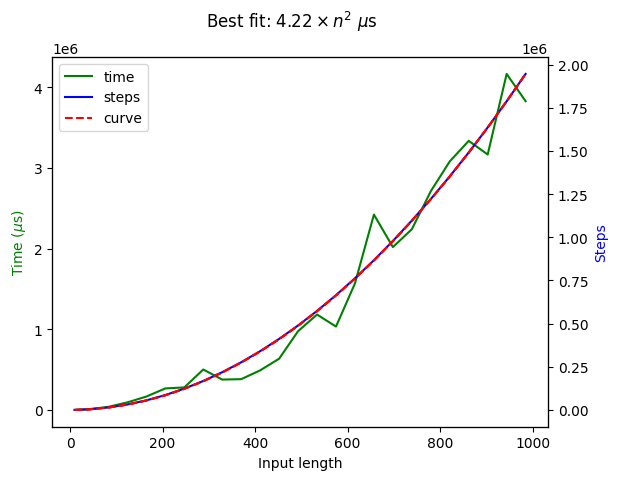

In [34]:
c , *_ = timer(selection_sort,genintlist(1000))

In [35]:
c(10**9)

4216509740843.5103

In [36]:
print(f'Sorting a billion items takes {int(c(10**9)/ (24*3600*365)):,} years!') 

Sorting a billion items takes 133,704 years!


## Can we sort faster than $O(n^2)$?

## Yes: MergeSort

In [38]:
# merge two sorted lists A and B into one unified sorted list
def merge(A, B):
    C = []
    Aidx,Bidx = 0,0
    while Aidx < len(A) and Bidx < len(B):
        if A[Aidx] < B[Bidx]:
            C += [A[Aidx]]
            Aidx += 1
        else:
            C += [B[Bidx]]
            Bidx += 1
    return C + A[Aidx:] + B[Bidx:]
        

def merge_sort(L):
    if len(L) <= 1:
        return L[:]
    else:
        A = merge_sort(L[:len(L)//2])
        B = merge_sort(L[len(L)//2:])
        return merge(A,B)

In [39]:
# can also use a recursive implementation of merge
def recursive_merge(A, B):
    if len(A) == 0:
        return B[:]
    elif len(B) == 0:
        return A[:]
    elif A[0] < B[0]:
        return [A[0]] + merge(A[1:], B)
    else:
        return [B[0]] + merge(A, B[1:])

In [40]:
merge_sort([5,4,3,2,1])

[1, 2, 3, 4, 5]

In [5]:
print(list(range(10,0,-1)))

[10, 9, 8, 7, 6, 5, 4, 3, 2, 1]


In [42]:
big_list = list(range(20000,0,-1))

In [43]:
merge_sort(big_list)
'done'

'done'

In [44]:
# remember this slow O(n^2) implementation... def iterative_selection_sort(L):
def iterative_selection_sort(L):
    A = L[:]
    for i in range(len(A)):
        # try to find index idx of the min element in L[i:],
        # then move it to L[i]
        idx = i
        for j in range(i+1, len(A)):
            if A[j] < A[idx]:
                idx = j
        
        # swap contents of A[i] and A[idx]
        tmp = A[i]
        A[i] = A[idx]
        A[idx] = tmp
    return A

In [45]:
iterative_selection_sort(big_list)
'done'

'done'

Central to computer science is the idea of _how to represent information_, and then how to create algorithms or programs that process those representations to compute useful things.

For example, I may be a shopkeeper and want to keep track of the items I've sold throughout the day, and how much I was paid for them.

`L = [ ['soap', 250], ['yam', 500] , ['yam', 500], ... ]`

Then, given that representation I may want to compute various things, such as "what were my gross sales yesterday?", or "how many times did I sell a yam"? I can then write programs to process this list L to find these answers.

A graph is just yet another way to represent information, and in the case of graphs, I want to represent information about _connections_ between pairs of objects (for example the "objects" could be people, and a "connection" could be that one person follows another on Instagram --- or the "objects" could be road intersections, and the "connections" are the road segments connecting one intersection to another).

When we talk about graphs, we call these "objects" **vertices**, and we call the "connections" **edges**. We will see more about graphs, and how to run algorithms on graphs, in the afternoon.